In [1]:
import sys
sys.path.append("../scripts") # project root so we can import data_collection

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sqlalchemy import text
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from data_collection import engine

In [2]:
# ── Load base dataset (same query as feature_engineering.ipynb) ──
with engine.connect() as conn:
    df = pd.read_sql(text("""
        SELECT
            w.game_id,
            w.date,
            w.season,
            w.home_away,
            w.tb,
            w.opponent_id,
            p.throws,
            p.era,
            p.whip,
            p.k_per_9,
            pf.park_factor,
            pf.park_factor_1b,
            pf.park_factor_2b,
            pf.park_factor_3b,
            pf.park_factor_hr
        FROM witt_game_logs w
        JOIN pitcher_game_logs p ON w.game_id = p.game_id
        JOIN park_factors pf ON (
            CASE WHEN w.home_away = 'home' THEN 118
                 ELSE w.opponent_id
            END = pf.team_id
        )
        ORDER BY w.date
    """), conn)

print(df.shape)
print(df.head())

(626, 15)
   game_id        date  season home_away  tb  opponent_id throws  era  whip  \
0   662766  2022-04-07    2022      home   2          114      R  4.2   1.3   
1   662765  2022-04-09    2022      home   0          114      R  4.2   1.3   
2   662755  2022-04-10    2022      home   2          114      R  4.2   1.3   
3   662754  2022-04-11    2022      home   0          114      R  4.2   1.3   
4   662017  2022-04-12    2022      away   0          138      R  4.2   1.3   

   k_per_9  park_factor  park_factor_1b  park_factor_2b  park_factor_3b  \
0      8.8           97             100              99             106   
1      8.8           97             100              99             106   
2      8.8           97             100              99             106   
3      8.8           97             100              99             106   
4      8.8           97             103             108             109   

   park_factor_hr  
0             212  
1             212  
2   

In [3]:
# ── Feature engineering ──
df = df.sort_values("date").reset_index(drop=True)

df["tb_avg_7"]  = df["tb"].shift(1).rolling(7,  min_periods=3).mean()
df["tb_avg_15"] = df["tb"].shift(1).rolling(15, min_periods=7).mean()
df["tb_lag1"]   = df["tb"].shift(1)
df["is_home"]   = (df["home_away"] == "home").astype(int)
df["pitcher_r"] = (df["throws"] == "R").astype(int)

df_model = df.dropna(subset=["tb_avg_7", "tb_avg_15", "tb_lag1"]).reset_index(drop=True)

print(df_model.shape)

(619, 20)


In [4]:
# ── Define features and target ──
FEATURES = [
    "tb_lag1",
    "tb_avg_7",
    "tb_avg_15",
    "is_home",
    "pitcher_r",
    "era",
    "whip",
    "k_per_9",
    "park_factor",
    "park_factor_1b",
    "park_factor_2b",
    "park_factor_3b",
    "park_factor_hr",
]

TARGET = "tb"

X = df_model[FEATURES]
y = df_model[TARGET]

print(X.shape)
print(y.describe())

(619, 13)
count    619.000000
mean       2.017771
std        1.993032
min        0.000000
25%        0.500000
50%        2.000000
75%        3.000000
max       11.000000
Name: tb, dtype: float64


In [5]:
# ── Baseline: naive mean predictor ──
# Before building any model, see what we're beating.
# If we always predict the training mean, what's the MAE?
naive_pred = np.full(len(y), y.mean())
naive_mae  = mean_absolute_error(y, naive_pred)
print(f"Naive baseline MAE (always predict mean): {naive_mae:.3f}")

Naive baseline MAE (always predict mean): 1.511


In [11]:
# ── Cross-validation with TimeSeriesSplit ──
model = XGBRegressor(
    n_estimators=100,
    max_depth=2,
    learning_rate=0.05,
    subsample=0.6,
    colsample_bytree=0.6,
    min_child_weight=10,
    random_state=42,
)

tscv = TimeSeriesSplit(n_splits=5)

cv_mae  = -cross_val_score(model, X, y, cv=tscv, scoring="neg_mean_absolute_error")
cv_rmse = -cross_val_score(model, X, y, cv=tscv, scoring="neg_root_mean_squared_error")

print(f"CV MAE  per fold: {[round(v,3) for v in cv_mae]}")
print(f"CV RMSE per fold: {[round(v,3) for v in cv_rmse]}")
print(f"\nMAE  mean ± std: {cv_mae.mean():.3f} ± {cv_mae.std():.3f}")
print(f"RMSE mean ± std: {cv_rmse.mean():.3f} ± {cv_rmse.std():.3f}")
print(f"\nBaseline MAE:    {naive_mae:.3f}")
print(f"Improvement:     {naive_mae - cv_mae.mean():.3f}")

CV MAE  per fold: [np.float64(1.367), np.float64(1.802), np.float64(1.627), np.float64(1.357), np.float64(1.439)]
CV RMSE per fold: [np.float64(1.816), np.float64(2.425), np.float64(2.256), np.float64(1.813), np.float64(1.781)]

MAE  mean ± std: 1.518 ± 0.172
RMSE mean ± std: 2.018 ± 0.269

Baseline MAE:    1.511
Improvement:     -0.008


In [12]:
# ── Fit on full dataset ──
model.fit(X, y)

insample_preds = model.predict(X)
insample_mae   = mean_absolute_error(y, insample_preds)
insample_rmse  = root_mean_squared_error(y, insample_preds)

print(f"In-sample MAE:  {insample_mae:.3f}")
print(f"In-sample RMSE: {insample_rmse:.3f}")
print(f"CV MAE:         {cv_mae.mean():.3f}")
print(f"\nGap (CV - in-sample): {cv_mae.mean() - insample_mae:.3f}")
print("(large gap = overfitting)")

In-sample MAE:  1.424
In-sample RMSE: 1.839
CV MAE:         1.518

Gap (CV - in-sample): 0.095
(large gap = overfitting)


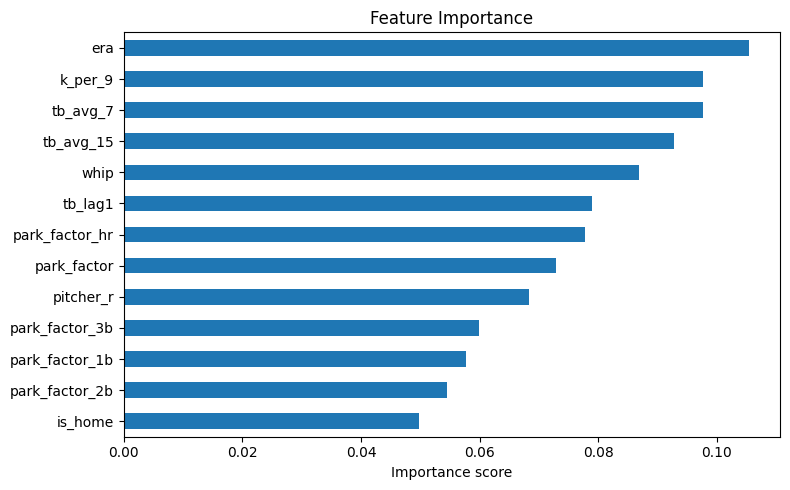

In [13]:
# ── Feature importance ──
importance = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importance.plot(kind="barh", ax=ax)
ax.set_title("Feature Importance")
ax.set_xlabel("Importance score")
plt.tight_layout()
plt.show()

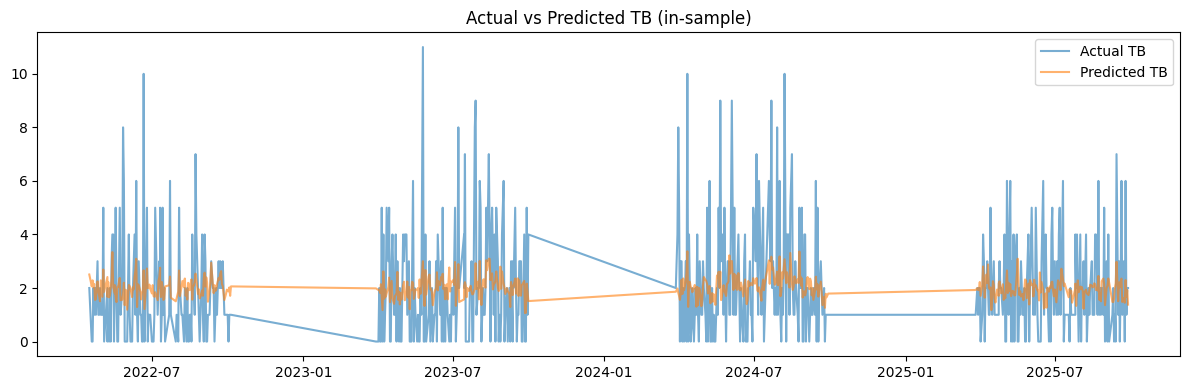

In [14]:
# ── Predicted vs actual ──
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_model["date"], y.values,             label="Actual TB",    alpha=0.6)
ax.plot(df_model["date"], insample_preds,        label="Predicted TB", alpha=0.6)
ax.set_title("Actual vs Predicted TB (in-sample)")
ax.legend()
plt.tight_layout()
plt.show()

In [15]:
# ── Save model ──
joblib.dump(model, "../models/witt_tb_model.pkl")
print("Model saved to models/witt_tb_model.pkl")

Model saved to models/witt_tb_model.pkl


In [16]:
print(df_model["tb"].value_counts().sort_index())
print(f"\nMean: {df_model['tb'].mean():.2f}")
print(f"Median: {df_model['tb'].median():.2f}")
print(f"\n% games with 0 TB: {(df_model['tb'] == 0).mean():.1%}")
print(f"% games with 1+ TB: {(df_model['tb'] >= 1).mean():.1%}")
print(f"% games with 2+ TB: {(df_model['tb'] >= 2).mean():.1%}")
print(f"% games with 3+ TB: {(df_model['tb'] >= 3).mean():.1%}")

tb
0     155
1     150
2     123
3      66
4      52
5      36
6      18
7       6
8       5
9       4
10      3
11      1
Name: count, dtype: int64

Mean: 2.02
Median: 2.00

% games with 0 TB: 25.0%
% games with 1+ TB: 75.0%
% games with 2+ TB: 50.7%
% games with 3+ TB: 30.9%
